# End-to-End Showcase of the Compression Pipeline

In [24]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
import os
import numpy as np
import matplotlib.pyplot as plt

from src.data import load_clip, save_clip, print_json_structure, extract_tracks

from src.compression.clip import ClipCompressor
from src.compression.baseline import RawBase64Compressor, QuantizeCompressor
from src.compression.blendshapes import BlendShapesSchemeCompressor

from src.preprocessing import AntipodalPreprocessor
from src.eval import memory_saving_matrix, plot_memory_usage_matrix

In [67]:
CLIP_IDX = 481

---
## Load Original Clip

In [68]:
orig_path = f"data/json/clip_{CLIP_IDX}.json"
orig_clip = load_clip(orig_path)

print_json_structure(orig_clip)

_id:
    $oid: <str>
animationClip:
    name: <str>
    duration: <float>
    tracks: [ 176 entries of
        name: <str>
        times: [ ~215 entries of <float> ]
        values: [ ~860 entries of <float> ]
        type: <str>
    ]
    uuid: <str>
    blendMode: <int>
recordDate: <int>


---
## Preprocssing

In [69]:
antipodal = AntipodalPreprocessor()

for track in orig_clip["animationClip"]["tracks"]:
    if track["type"] == "quaternion":
        track = antipodal.process(track)

---
## Baseline Compressions

In [70]:
rb64_com = ClipCompressor(
    blendshapes_compressor=RawBase64Compressor(type_name="number"),
    quaternions_compressor=RawBase64Compressor(type_name="quaternion"),
)

rb64_path = f"out/rb64/clip_{CLIP_IDX}_rb64.json"
rb64_clip = rb64_com.compress(orig_clip)
save_clip(rb64_clip, rb64_path)

print_json_structure(rb64_clip)

_id:
    $oid: <str>
animationClip:
    name: <str>
    duration: <float>
    uuid: <str>
    blendMode: <int>
    blendshape_tracks_data:
        compression_type: <str>
        type_name: <str>
        tracks: [ 129 entries of
            name: <str>
            times_b64: <str>
            values_b64: <str>
        ]
    quaternion_tracks_data:
        compression_type: <str>
        type_name: <str>
        tracks: [ 47 entries of
            name: <str>
            times_b64: <str>
            values_b64: <str>
        ]
recordDate: <int>


In [71]:
quan_com = ClipCompressor(
    blendshapes_compressor=QuantizeCompressor(type_name="number"),
    quaternions_compressor=QuantizeCompressor(type_name="quaternion", renormalize=True),
)

quan_path = f"out/quan/clip_{CLIP_IDX}_quan.json"
quan_clip = quan_com.compress(orig_clip)
save_clip(quan_clip, quan_path)

print_json_structure(quan_clip)

_id:
    $oid: <str>
animationClip:
    name: <str>
    duration: <float>
    uuid: <str>
    blendMode: <int>
    blendshape_tracks_data:
        compression_type: <str>
        type_name: <str>
        q_bits: <int>
        tracks: [ 129 entries of
            name: <str>
            q_times:
                codes_b64: <str>
                scale: <float64>
                zero: <float64>
            q_values:
                codes_b64: <str>
                scale: <float64>
                zero: <float64>
        ]
    quaternion_tracks_data:
        compression_type: <str>
        type_name: <str>
        q_bits: <int>
        tracks: [ 47 entries of
            name: <str>
            q_times:
                codes_b64: <str>
                scale: <float64>
                zero: <float64>
            q_values:
                x:
                    codes_b64: <str>
                    scale: <float64>
                    zero: <float64>
                y:
                    code

---
## Blendshapes Scheme

In [72]:
bsch_com = ClipCompressor(
    blendshapes_compressor=BlendShapesSchemeCompressor(type_name="number", decimation_thres=0),
    quaternions_compressor=QuantizeCompressor(type_name="quaternion", renormalize=True),
)

bsch_path = f"out/bsch/clip_{CLIP_IDX}_bsch.json"
bsch_clip = bsch_com.compress(orig_clip)
save_clip(bsch_clip, bsch_path)

print_json_structure(bsch_clip)

_id:
    $oid: <str>
animationClip:
    name: <str>
    duration: <float>
    uuid: <str>
    blendMode: <int>
    blendshape_tracks_data:
        compress_type: <str>
        type_name: <str>
        q_bits: <int>
        f_fps: <int>
        groups: [ 50 entries of
            names: [ ~3 entries of <str> ]
            f_times_b64: <str>
            q_values:
                codes_b64: <str>
                scale: <float64>
                zero: <float64>
        ]
    quaternion_tracks_data:
        compression_type: <str>
        type_name: <str>
        q_bits: <int>
        tracks: [ 47 entries of
            name: <str>
            q_times:
                codes_b64: <str>
                scale: <float64>
                zero: <float64>
            q_values:
                x:
                    codes_b64: <str>
                    scale: <float64>
                    zero: <float64>
                y:
                    codes_b64: <str>
                    scale: <float64>
  

---
## Decoding Test

In [73]:
decom_clip = bsch_com.decompress(bsch_clip)
print(decom_clip["animationClip"]["tracks"][-1]["values"])

[0.44169171021160225, -0.49627067447410983, 0.4423107617333293, 0.602482398782109, 0.4417644864936272, -0.49619243494178505, 0.4423160489314341, 0.6024896006050638, 0.4417488189766352, -0.4961748370957756, 0.44230036185285637, 0.6025270963787112, 0.4417672670673848, -0.4961113858238796, 0.4423188329768606, 0.602552258810563, 0.4418943556067033, -0.4960183400193176, 0.442310920246752, 0.6025414796326378, 0.44195381946102136, -0.49600932579482165, 0.44219632872398185, 0.6025893934109807, 0.4420965655935388, -0.4959338583874076, 0.4422040877939892, 0.602541101945471, 0.44216654840711167, -0.495936647995014, 0.4422065751738404, 0.602485625984748, 0.44216654840711167, -0.495936647995014, 0.4422065751738404, 0.602485625984748, 0.44215323965854003, -0.49600588947887925, 0.44208671262647614, 0.6025263552582897, 0.44222321900269174, -0.49600867709552804, 0.4420891972104427, 0.6024708777448649, 0.4422204373677023, -0.4960897257433606, 0.44208641641846574, 0.602408224715163, 0.4421448869287381, -

---
## Evaluation

In [74]:
paths = [orig_path, rb64_path, quan_path, bsch_path]
names = ["Original", "RawBase64", "DirectQuantize", "BlendshapesScheme"]

print("===== MEMOEY USAGES =====\n")
for p, n in zip(paths, names):
    if n == "Original":
        blendshapes = extract_tracks(orig_clip["animationClip"]["tracks"], type="number")
        quaternions = extract_tracks(orig_clip["animationClip"]["tracks"], type="quaternion")

    else:
        clip = load_clip(p)
        blendshapes = clip["animationClip"].pop("blendshape_tracks_data", None)
        quaternions = clip["animationClip"].pop("quaternion_tracks_data", None)

    save_clip(blendshapes, "out/temp/blendshapes.json")
    save_clip(quaternions, "out/temp/quaternions.json")
    blendshapes_size = os.path.getsize("out/temp/blendshapes.json") // 1024
    quaternions_size = os.path.getsize("out/temp/quaternions.json") // 1024
    ratio = blendshapes_size / (blendshapes_size + quaternions_size)

    str1 = f"{n:<20} : {f"{os.path.getsize(p) // 1024:,}" + " KB":<10} | "
    str2 = f" blendshapes size: {f"{blendshapes_size:,}" + " KB":<9} | "
    str3 = f" quaternions size: {f"{quaternions_size:,}" + " KB":<9} | "
    str5 = f"({round(100 * ratio)} / {round(100 * (1 - ratio))})"

    print(str1 + str2 + str3 + str5)

===== MEMOEY USAGES =====

Original             : 3,769 KB   |  blendshapes size: 1,371 KB  |  quaternions size: 1,666 KB  | (45 / 55)
RawBase64            : 991 KB     |  blendshapes size: 455 KB    |  quaternions size: 529 KB    | (46 / 54)
DirectQuantize       : 238 KB     |  blendshapes size: 104 KB    |  quaternions size: 109 KB    | (49 / 51)
BlendshapesScheme    : 175 KB     |  blendshapes size: 50 KB     |  quaternions size: 109 KB    | (31 / 69)


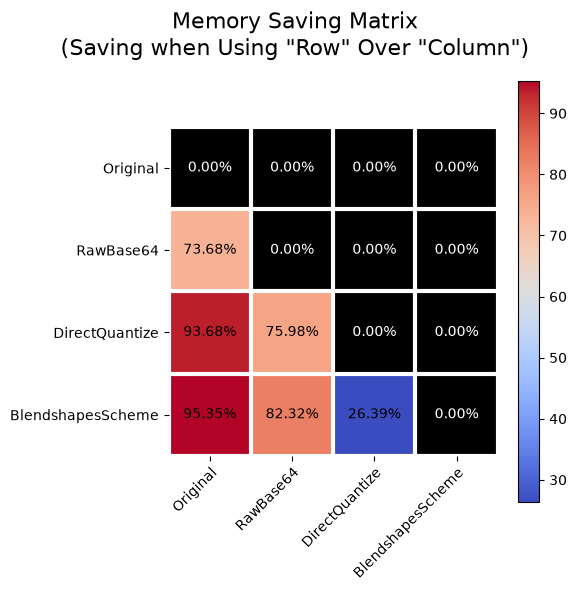

In [75]:
matrix = memory_saving_matrix(paths=paths, names=names, clip_negs=True)
plot_memory_usage_matrix(matrix)